# Decomposição da Série Temporal

Nesta etapa será realizada a decomposição da série temporal de Trocas de Óleo da MecâniQA, buscando isolar os componentes de Tendência, Sazonalidade e Ruído.

Com base no Brainstorm da equipe, foi adotado:

- Modelo: Aditivo
- Periodicidade: 7 dias

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

## 2. Carregamento e preparação do dataset

In [2]:
df = pd.read_excel("../data/mecaniqa_dataset.xlsx")
df.head()

,Data,Trocas_Oleo,Manutencao_Motor
0,2024-01-01,11.0,2.0
1,2024-01-02,9.0,4.0
2,2024-01-03,12.0,1.0
3,2024-01-04,15.0,8.0
4,2024-01-05,25.0,10.0


In [3]:
df["Data"] = pd.to_datetime(df["Data"])

df = df.sort_values("Data")
df.set_index("Data", inplace=True)

df.head()

,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


## 3. Série temporal de Trocas de Óleo

In [4]:
serie_trocas_oleo = df["Trocas_Oleo"].resample("D").sum()

serie_trocas_oleo.head()

Data
2024-01-01    11.0
2024-01-02     9.0
2024-01-03    12.0
2024-01-04    15.0
2024-01-05    25.0
Freq: D, Name: Trocas_Oleo, dtype: float64

## 4. Decomposição da série temporal

In [5]:
decomposicao = seasonal_decompose(
    serie_trocas_oleo,
    model="additive",
    period=7
)

decomposicao

## 5. Visualização dos componentes

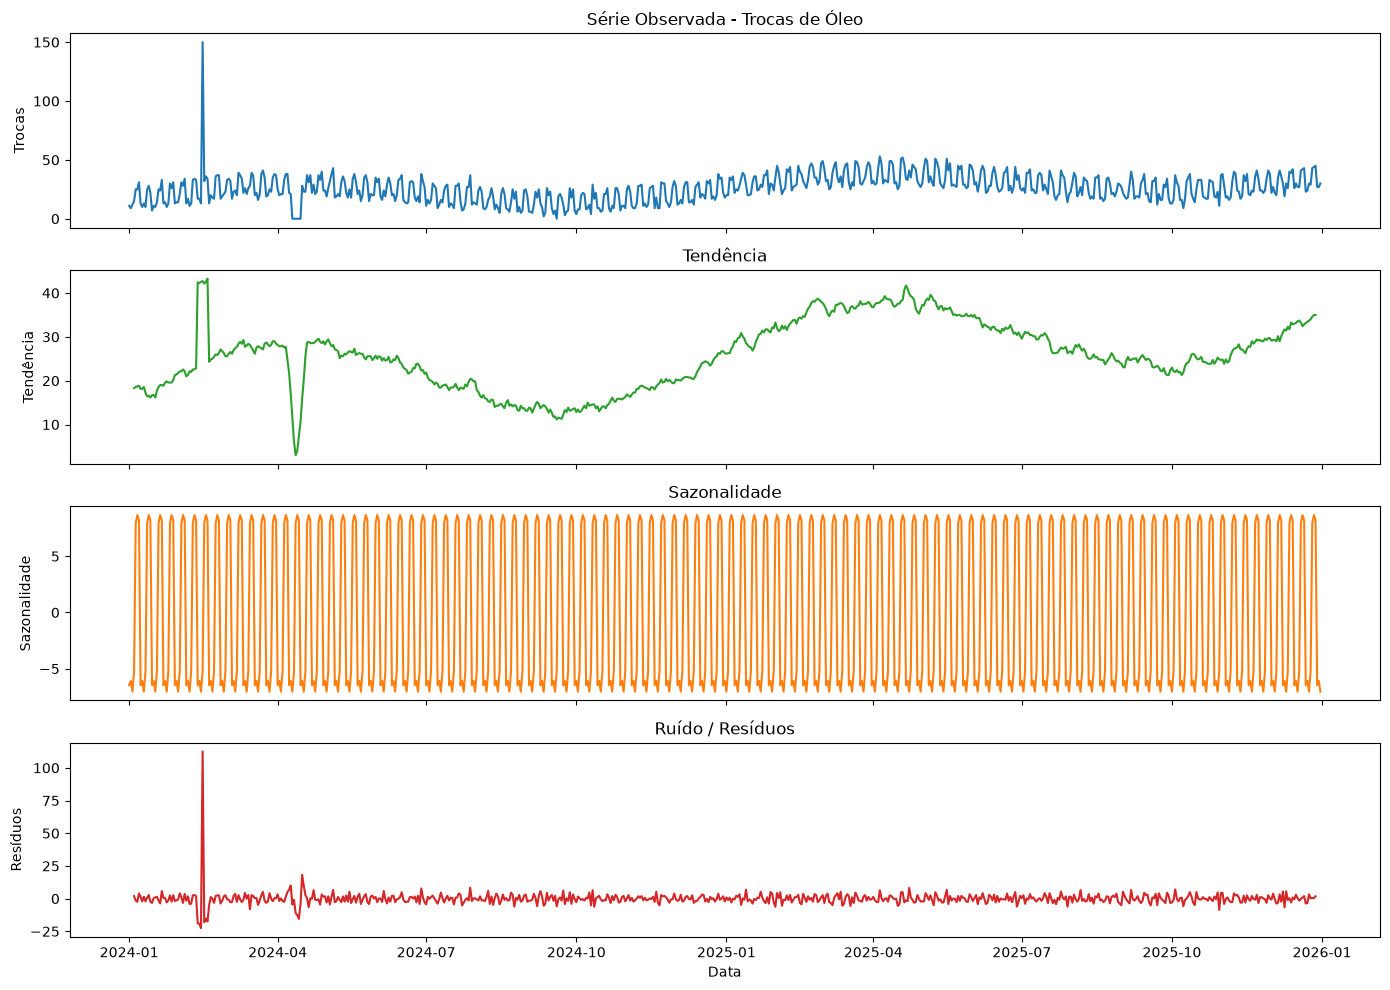

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(decomposicao.observed, color="#1f77b4")
axes[0].set_title("Série Observada - Trocas de Óleo")
axes[0].set_ylabel("Trocas")

axes[1].plot(decomposicao.trend, color="#2ca02c")
axes[1].set_title("Tendência")
axes[1].set_ylabel("Tendência")

axes[2].plot(decomposicao.seasonal, color="#ff7f0e")
axes[2].set_title("Sazonalidade")
axes[2].set_ylabel("Sazonalidade")

axes[3].plot(decomposicao.resid, color="#d62728")
axes[3].set_title("Ruído / Resíduos")
axes[3].set_ylabel("Resíduos")
axes[3].set_xlabel("Data")

plt.tight_layout()
plt.show()